In [256]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import torch.nn as nn
from torch.nn.functional import one_hot
import sklearn as sk
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import torch as torch
import joblib  
%matplotlib inline


In [174]:
df = pd.read_csv('../data/kc_house_data.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [175]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

A Clear pattern in data we can see is that all the data is either in int or float only data is in string format.
We need to make few changes and see convert some of the fields into catogorical data.


In [176]:
df.nunique()

id               21436
date               372
price             4028
bedrooms            13
bathrooms           30
sqft_living       1038
sqft_lot          9782
floors               6
waterfront           2
view                 5
condition            5
grade               12
sqft_above         946
sqft_basement      306
yr_built           116
yr_renovated        70
zipcode             70
lat               5034
long               752
sqft_living15      777
sqft_lot15        8689
dtype: int64

In [177]:
df.describe()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,2.161300e+04,21613.000000,21613.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,4.580302e+09,5.400881e+05,3.370842,2.114757,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,2.876566e+09,3.671272e+05,0.930062,0.770163,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,1.000102e+06,7.500000e+04,0.000000,0.000000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,2.123049e+09,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,3.904930e+09,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,7.308900e+09,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,9.900000e+09,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [178]:
df.isna().sum()

id               0
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64

One good thing about this dataset we dont have any missing values it makes things little easy.

In [179]:
df.duplicated().sum()

np.int64(0)

There is also no duplicated values so we dont need to spend much time on cleaning the dataset.

In [180]:
# WE are going to drop the columns that are not useful for our model and also the target variable
X = df.drop(['price','id','sqft_above','date'], axis=1)
y = df['price']


In [181]:
X.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,0,1955,0,98178,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,0,1933,0,98028,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,910,1965,0,98136,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,0,1987,0,98074,47.6168,-122.045,1800,7503


In [182]:
y.head()


0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [183]:
catogorical_cols = ["bedrooms", "bathrooms", "floors", "waterfront", "view", "condition", "grade"]

<Figure size 640x480 with 0 Axes>

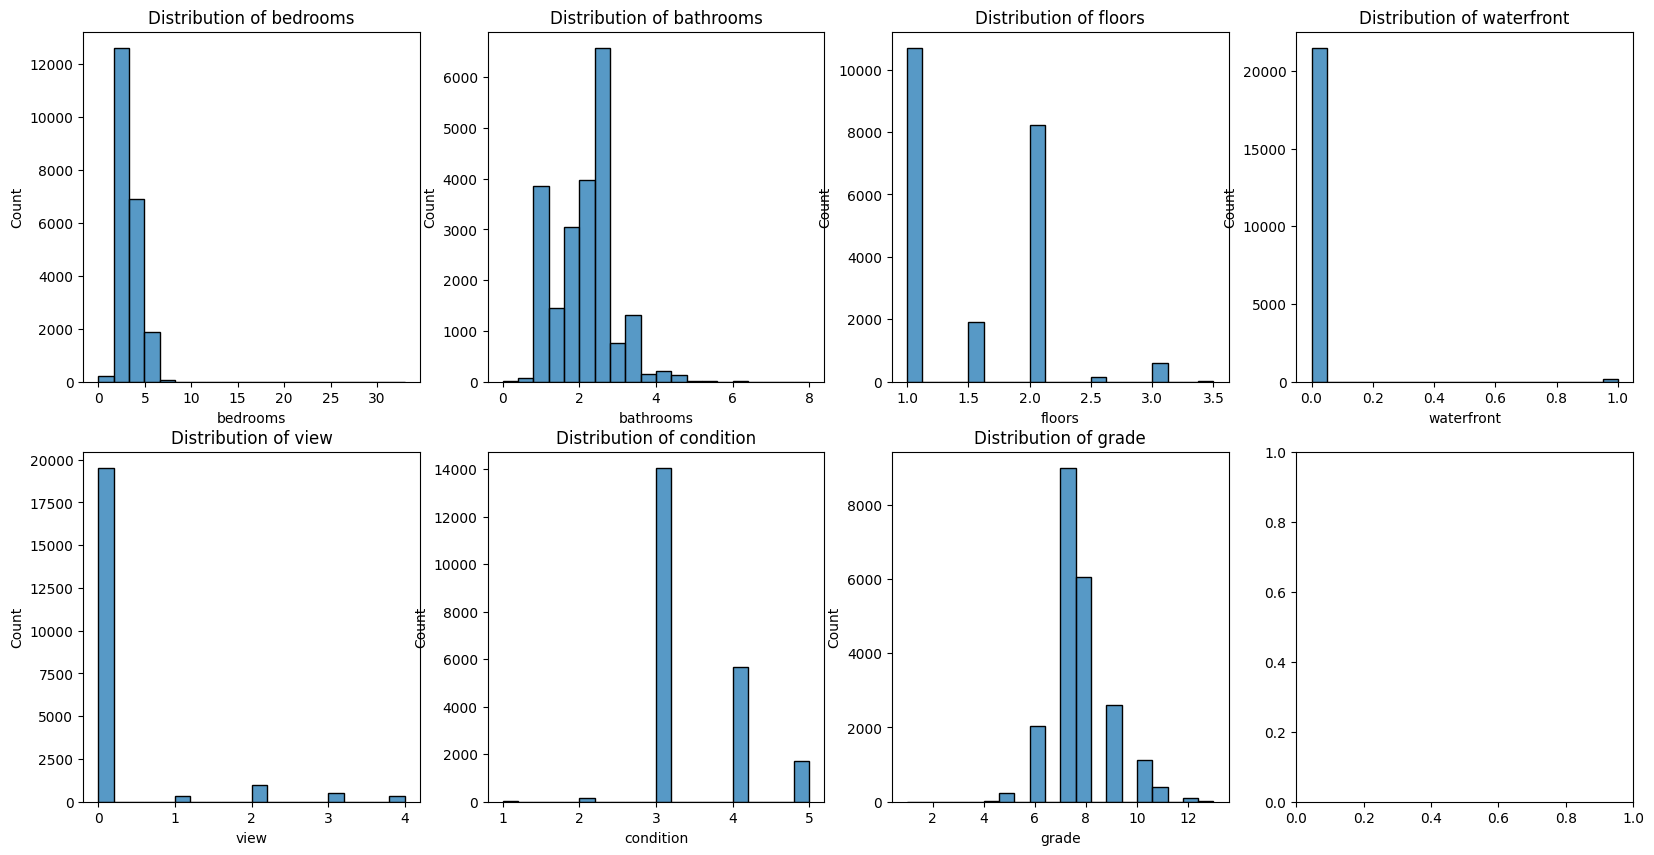

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [184]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(catogorical_cols):
    plt.figure(i)
    sns.histplot(X[col], bins=20, ax=ax[i//4, i%4], element="bars")
    ax[i//4, i%4].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

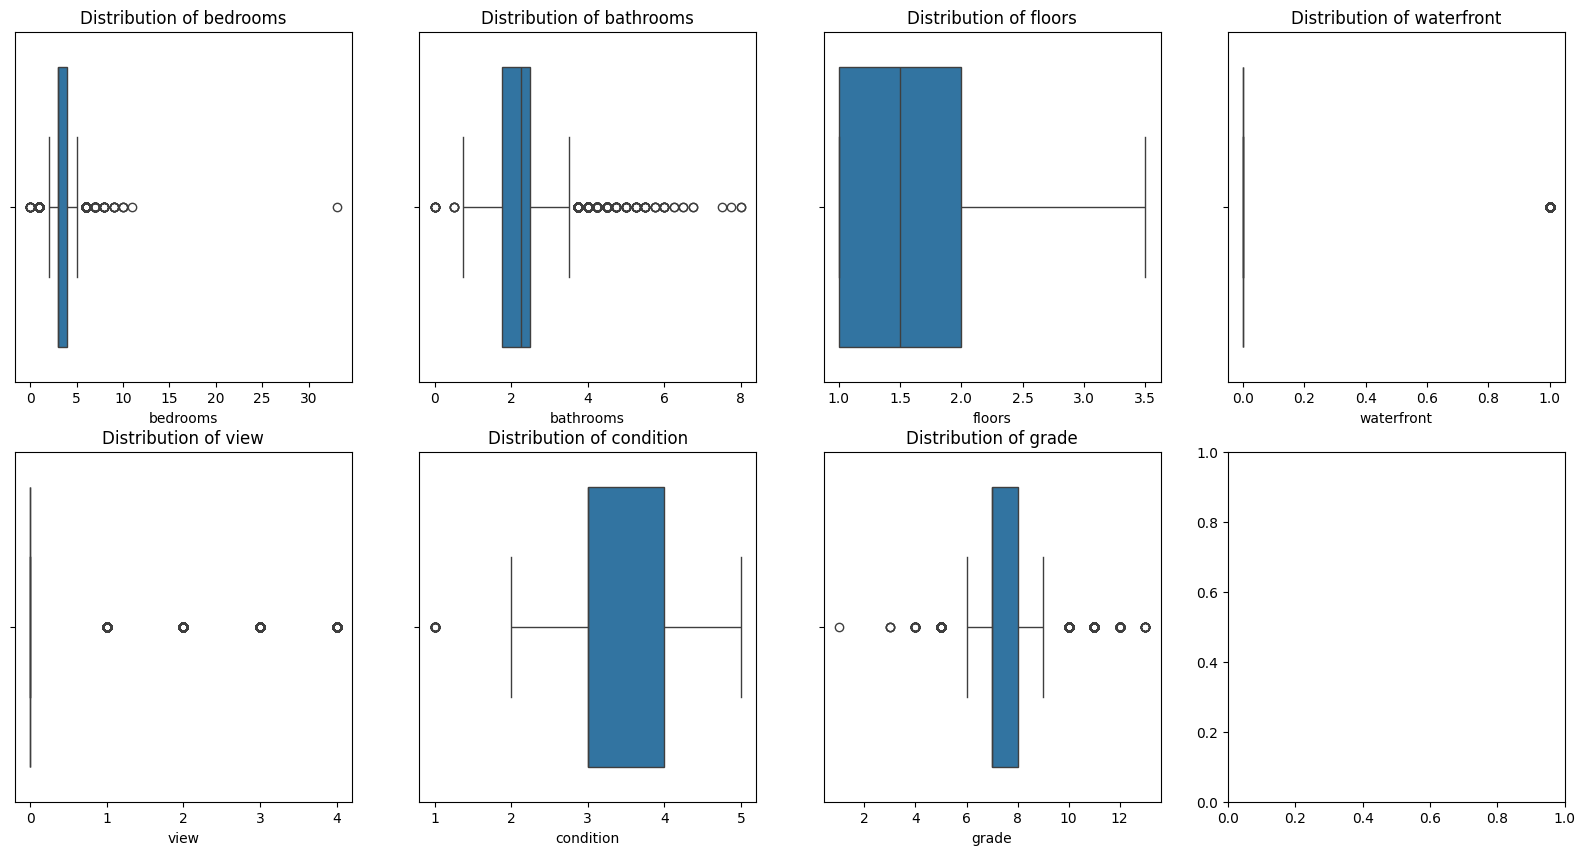

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [185]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(catogorical_cols):
    plt.figure(i)
    sns.boxplot(x=X[col], ax=ax[i//4, i%4])
    ax[i//4, i%4].set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


<Figure size 640x480 with 0 Axes>

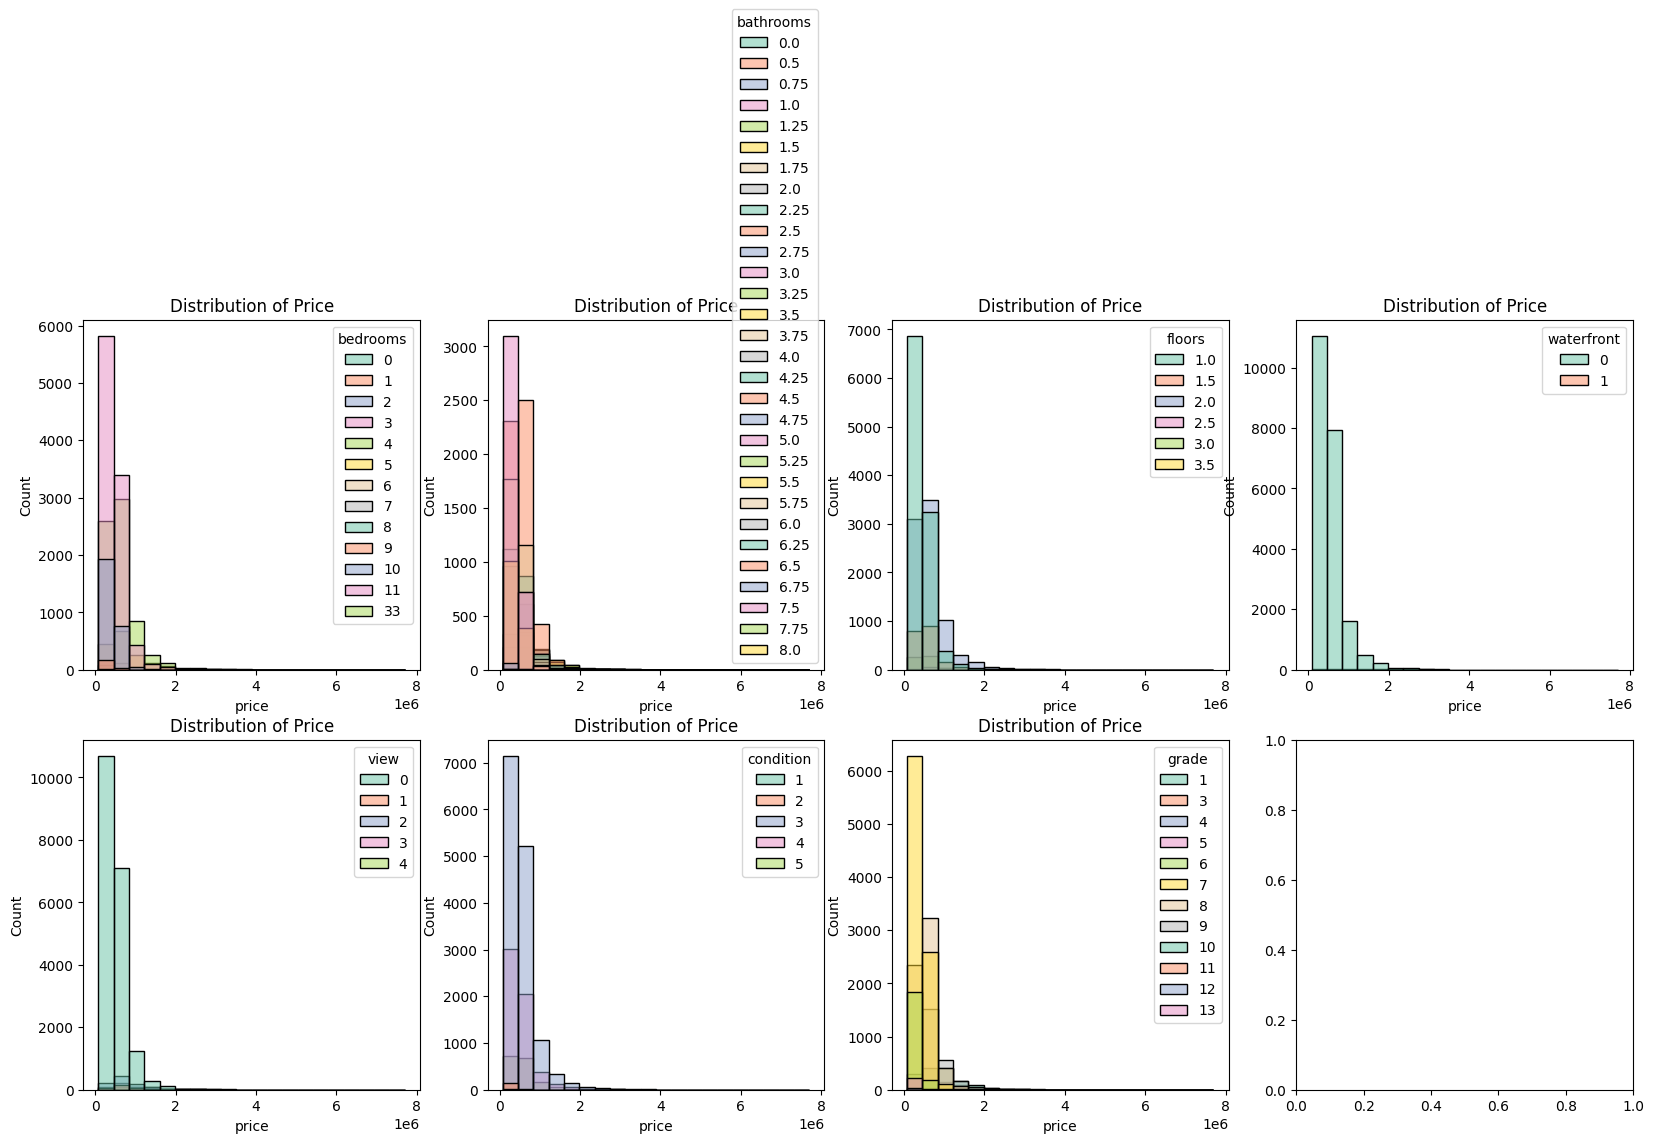

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [186]:
fig, ax = plt.subplots(2, 4, figsize=(20, 10))

for i, col in enumerate(catogorical_cols):
    plt.figure(i)
    sns.histplot(df, x="price", bins=20, ax=ax[i//4, i%4], element="bars", hue=col, palette="Set2")
    ax[i//4, i%4].set_title(f"Distribution of Price")

plt.tight_layout()
plt.show()


C:\Users\devgu\AppData\Local\Temp\ipykernel_3256\3455489881.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=df["yr_built"], y=df["price"], palette="Set2")


Text(0.5, 1.0, 'Price vs Year Built')

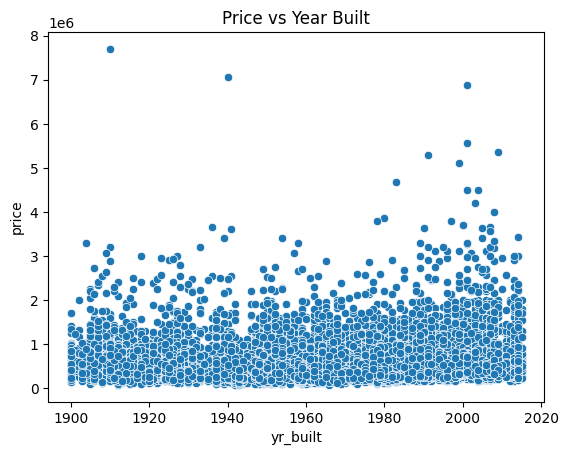

In [187]:

sns.scatterplot(x=df["yr_built"], y=df["price"], palette="Set2")
plt.title("Price vs Year Built")

C:\Users\devgu\AppData\Local\Temp\ipykernel_3256\2899925088.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x=df["yr_renovated"], y=df["price"], palette="Set2")


Text(0.5, 1.0, 'Price vs Year Renovated')

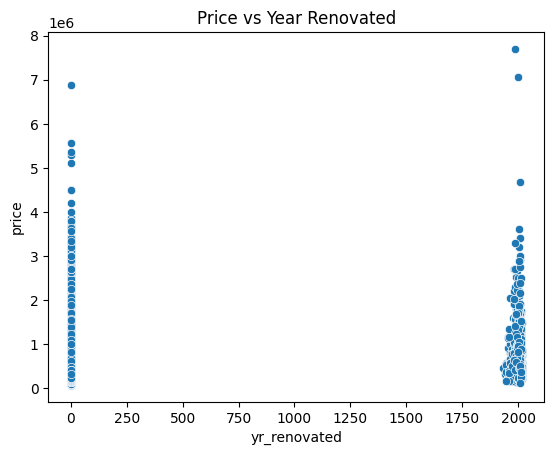

In [188]:
sns.scatterplot(x=df["yr_renovated"], y=df["price"], palette="Set2")
plt.title("Price vs Year Renovated")

In [190]:
encoder = OneHotEncoder()
scaler = StandardScaler()


In [191]:
categorical_cols = ['zipcode']

In [192]:
nummerical_cols = [col for col in X.columns if col not in categorical_cols]

In [195]:
X['zipcode'] = X['zipcode'].astype(str) # Force them to be text
X = pd.get_dummies(X, columns=['zipcode'], drop_first=True) # Create the column



In [198]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

In [199]:
train_X_scaled = scaler.fit_transform(train_X)
test_X_scaled = scaler.transform(test_X)

In [200]:
X_train_tensor = torch.FloatTensor(train_X_scaled)
X_test_tensor = torch.FloatTensor(test_X_scaled)
y_train_tensor = torch.FloatTensor(train_y.values).view(-1, 1) 
y_test_tensor = torch.FloatTensor(test_y.values).view(-1, 1)

C:\Users\devgu\AppData\Local\Temp\ipykernel_3256\2980737958.py:3: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_numpy.cpp:212.)
  y_train_tensor = torch.FloatTensor(train_y.values).view(-1, 1)


In [201]:
print (X_train_tensor.shape[1])

85


In [240]:
input_dim = X_train_tensor.shape[1]

class HousingPriceModel(nn.Module):
    def __init__(self, input_dim):
        super(HousingPriceModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 1)
        #self.fc4 = nn.Linear(16, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        #x = torch.relu(self.fc3(x))
        x = self.fc3(x)
        return x
    

model = HousingPriceModel(input_dim)

print("Model Architecture:")
print(model)

Model Architecture:
HousingPriceModel(
  (fc1): Linear(in_features=85, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)


In [241]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [248]:
epochs = 3000

train_losses = []

for epoch in range(epochs):
    model.train()
    
    
    y_pred = model(X_train_tensor)
    loss = loss_fn(y_pred, y_train_tensor)
    train_losses.append(loss.item())
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()
    
    if (epoch+1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [50/3000], Loss: 13782563840.0000
Epoch [100/3000], Loss: 13743734784.0000
Epoch [150/3000], Loss: 13704278016.0000
Epoch [200/3000], Loss: 13665794048.0000
Epoch [250/3000], Loss: 13627750400.0000
Epoch [300/3000], Loss: 13589407744.0000
Epoch [350/3000], Loss: 13549981696.0000
Epoch [400/3000], Loss: 13510730752.0000
Epoch [450/3000], Loss: 13472226304.0000
Epoch [500/3000], Loss: 13433828352.0000
Epoch [550/3000], Loss: 13396092928.0000
Epoch [600/3000], Loss: 13358396416.0000
Epoch [650/3000], Loss: 13320594432.0000
Epoch [700/3000], Loss: 13283518464.0000
Epoch [750/3000], Loss: 13246801920.0000
Epoch [800/3000], Loss: 13209923584.0000
Epoch [850/3000], Loss: 13172014080.0000
Epoch [900/3000], Loss: 13134099456.0000
Epoch [950/3000], Loss: 13097515008.0000
Epoch [1000/3000], Loss: 13059172352.0000
Epoch [1050/3000], Loss: 13019437056.0000
Epoch [1100/3000], Loss: 12979230720.0000
Epoch [1150/3000], Loss: 12941184000.0000
Epoch [1200/3000], Loss: 12902010880.0000
Epoch [1250/

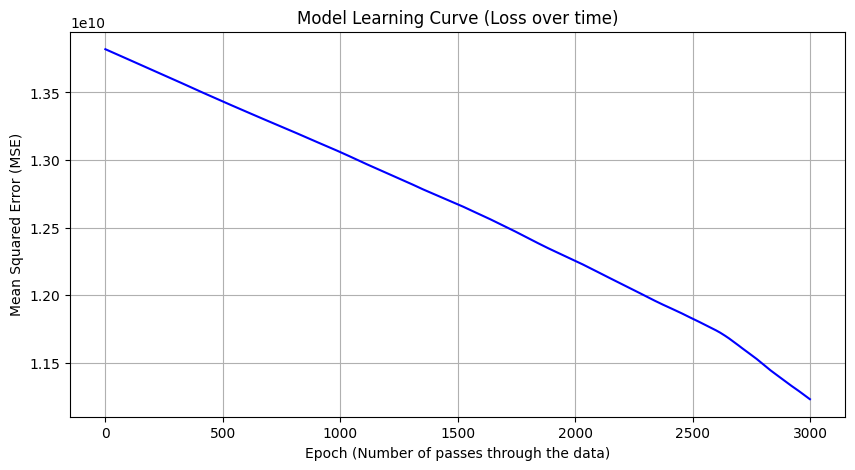

In [249]:
import matplotlib.pyplot as plt
import numpy as np

# Plot the training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, color='blue')
plt.title('Model Learning Curve (Loss over time)')
plt.xlabel('Epoch (Number of passes through the data)')
plt.ylabel('Mean Squared Error (MSE)')
plt.grid(True)
plt.show()

In [250]:
# 1. Put the model in Evaluation Mode
model.eval()

# 2. Turn off gradient calculations
with torch.no_grad():
    
    y_test_pred = model(X_test_tensor)
    test_loss = loss_fn(y_test_pred, y_test_tensor)
    mae = torch.mean(torch.abs(y_test_pred - y_test_tensor))

print(f"Final Test MSE: {test_loss.item():.2f}")
print(f"On average, your model's price predictions are off by: ${mae.item():,.2f}")

Final Test MSE: 17845835776.00
On average, your model's price predictions are off by: $72,511.47


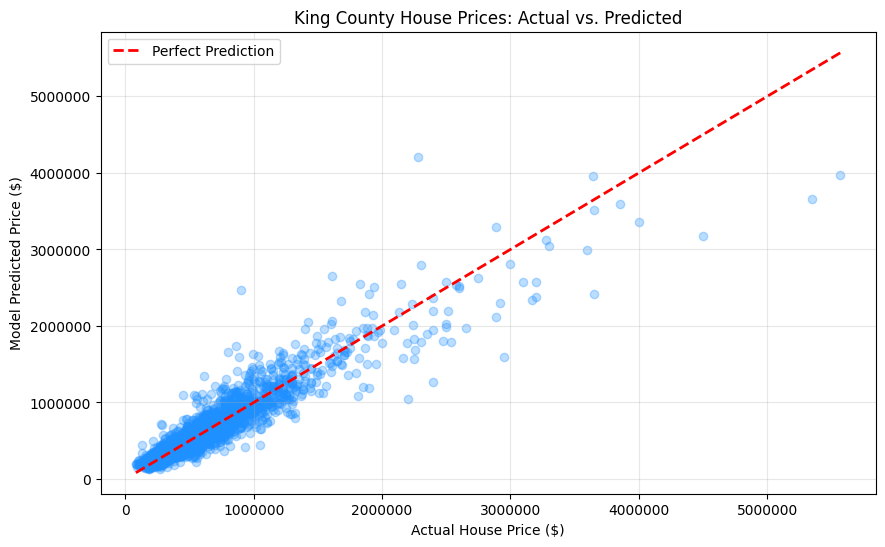

In [245]:
# First, we need to convert our PyTorch tensors back into regular NumPy arrays for plotting
y_test_actual = y_test_tensor.numpy()
y_test_predictions = y_test_pred.numpy() # This is the y_test_pred from our evaluation step

plt.figure(figsize=(10, 6))
# Create the scatter plot (alpha=0.3 makes the dots slightly transparent so we can see overlapping)
plt.scatter(y_test_actual, y_test_predictions, alpha=0.3, color='dodgerblue')

# Draw the "Perfect Prediction" red dashed line
max_price = max(y_test_actual.max(), y_test_predictions.max())
min_price = min(y_test_actual.min(), y_test_predictions.min())
plt.plot([min_price, max_price], [min_price, max_price], color='red', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('King County House Prices: Actual vs. Predicted')
plt.xlabel('Actual House Price ($)')
plt.ylabel('Model Predicted Price ($)')

# This stops matplotlib from using scientific notation (like 1e6) on the axes
plt.ticklabel_format(style='plain', axis='both')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [251]:
model_save_path = "../model/kc_house_predictor.pth"
torch.save(model.state_dict(), model_save_path)

print(f"Model successfully saved to {model_save_path}!")

Model successfully saved to ../model/kc_house_predictor.pth!


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error
y_true = y_test_tensor.numpy()
y_predictions = y_test_pred.numpy() 
r2 = r2_score(y_true, y_predictions)
mae = mean_absolute_error(y_true, y_predictions)

print(f"📊 Model 'Accuracy' (R-squared): {r2 * 100:.2f}%")
print(f"💵 Average Prediction Error: ${mae:,.2f}")

📊 Model 'Accuracy' (R-squared): 88.20%
💵 Average Prediction Error: $72,511.47


In [ ]:
import pandas as pd
import torch

# --- 1. DESIGN YOUR DREAM HOUSE ---
# Fill in the specs for the house you want to appraise
my_dream_house = {
    'bedrooms': [3],               # 3 beds
    'bathrooms': [2.5],            # 2.5 baths
    'sqft_living': [2500],         # 2,500 sqft inside
    'sqft_lot': [6000],            # 6,000 sqft of land
    'floors': [2.0],               # 2 stories
    'waterfront': [0],             # 0 = No, 1 = Yes
    'view': [0],                   # View quality (0-4)
    'condition': [3],              # Condition (1-5)
    'grade': [8],                  # Construction grade (1-13)
    'sqft_basement': [500],        # 500 sqft basement
    'yr_built': [2005],            # Built in 2005
    'yr_renovated': [0],           # 0 if never renovated
    'zipcode': ['98003'],          # Make sure it's a string in brackets!
    'lat': [47.32],                # Latitude
    'long': [-122.31],             # Longitude
    'sqft_living15': [2000],       # Neighbors' house size
    'sqft_lot15': [6000]           # Neighbors' lot size
}

new_house_df = pd.DataFrame(my_dream_house)


new_house_encoded = pd.get_dummies(new_house_df, columns=['zipcode'])

new_house_encoded = new_house_encoded.reindex(columns=X.columns, fill_value=0)


new_house_scaled = scaler.transform(new_house_encoded)


new_house_tensor = torch.FloatTensor(new_house_scaled)


model.eval() 
with torch.no_grad():
    predicted_price = model(new_house_tensor)

print(f"🏠 The Neural Network predicts this house is worth: ${predicted_price.item():,.2f}")

🏠 The Neural Network predicts this house is worth: $328,846.28


In [258]:
# Bundle everything into a single dictionary
bundle = {
    'model_state': model.state_dict(),
    'scaler': scaler,
    'columns': X.columns.tolist()
}
joblib.dump(bundle, "../full_model_package.pkl")

['../full_model_package.pkl']